[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


First 5 Rows
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Shape:
(50000, 2)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Missing Values:
review       0
sentiment    0
dtype: int64

Sentiment Count:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


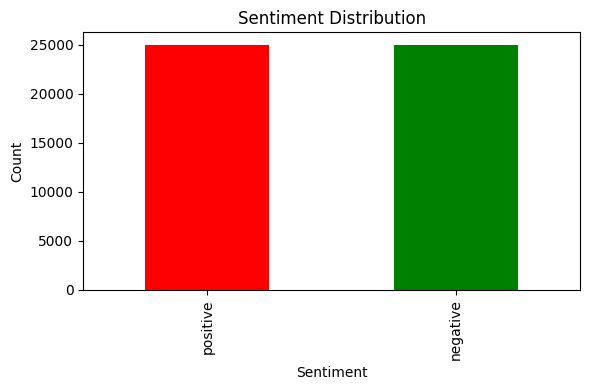


Cleaning reviews...
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one review mention watch oz episod hook right ...  
1  wonder littl product film techniqu unassum old...  
2  thought wonder way spend time hot summer weeke...  
3  basic famili littl boy jake think zombi closet...  
4  petter mattei love time money visual stun film...  

Training Shape: (40000, 5000)
Testing Shape: (10000, 5000)

Training Logistic Regression...

Accuracy : 88.63%

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy

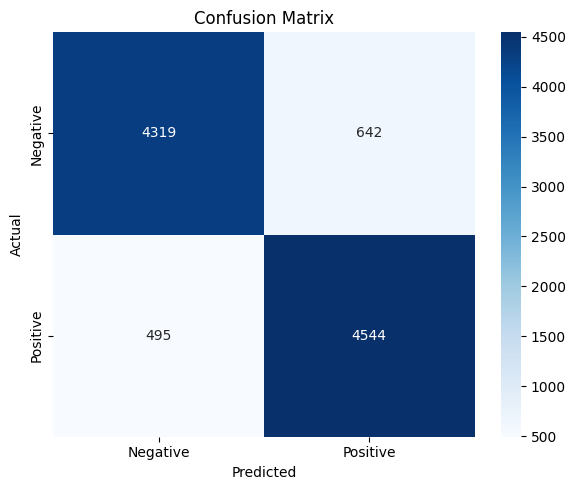


Enter Movie Review (type exit to stop): there is a small boyy the story is based upon him onlyy.
Prediction : Positive 😊

Enter Movie Review (type exit to stop): exit

Files Saved Successfully!
model.pkl
vectorizer.pkl


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
nltk.download("stopwords")
df = pd.read_csv("IMDB Dataset.csv")
print("First 5 Rows")
print(df.head())
print("\nShape:")
print(df.shape)
print("\nInfo:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSentiment Count:")
print(df["sentiment"].value_counts())
#sentiment
plt.figure(figsize=(6,4))
df["sentiment"].value_counts().plot(kind="bar", color=["red","green"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
# Encode Labels
df["sentiment"] = df["sentiment"].map({
    "positive":1,
    "negative":0
})

# Text Cleaning
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"[^a-zA-Z]"," ",text)
    text = text.lower()
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

print("\nCleaning reviews...")
df["clean_review"] = df["review"].apply(clean_text)

print(df[["review","clean_review"]].head())
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])
y = df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)
print("\nTraining Logistic Regression...")

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test,y_pred)

print(f"\nAccuracy : {accuracy*100:.2f}%")
# Classification Report
print("\nClassification Report\n")
print(classification_report(y_test,y_pred))
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)

print("\nConfusion Matrix\n")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# -----------------------------
# Test Custom Reviews
# -----------------------------
while True:
    review = input("\nEnter Movie Review (type exit to stop): ")

    if review.lower() == "exit":
        break

    cleaned = clean_text(review)

    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)

    if prediction[0] == 1:
        print("Prediction : Positive 😊")
    else:
        print("Prediction : Negative 😞")

# -----------------------------
# Save Model
# -----------------------------
joblib.dump(model,"model.pkl")
joblib.dump(vectorizer,"vectorizer.pkl")

print("\nFiles Saved Successfully!")
print("model.pkl")
print("vectorizer.pkl")
